# 04 — Bandpower Feature Visualisation

## Purpose
Visualise the time-binned bandpower features for a single trial to verify that
the feature extraction pipeline produces interpretable representations.

## Input files (from notebook 03)
- `bp_time_features_rich532_{session_id}.npy` — shape (N_trials, K=10, D=532)
- `bp_time_labels_rich532_{session_id}.npy`   — shape (N_trials,)

## What this notebook produces
- **Line plots** — per-channel bandpower amplitude across the 10 time bins,
  one line per frequency band; shows temporal dynamics within a trial
- **Heatmap** — frequency band × time bin matrix for selected channels;
  reveals which bands carry the most power at each temporal position

These visualisations are exploratory. Their purpose is to sanity-check the
extracted features and build intuition about the structure of the input data.

## ⚠️ Note on paths
Update `data_dir`, `sid`, and `common_D` in each cell to match your setup.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

X shape: (13785, 10, 532)
Example labels: ['dot_motion' 'drifting_gratings_75_repeats' 'drifting_gratings_contrast'
 'flashes' 'gabors' 'natural_movie_one_more_repeats'
 'natural_movie_one_shuffled' 'spontaneous']
D = 532
Inferred n_channels = 133
Selected label: natural_movie_one_shuffled


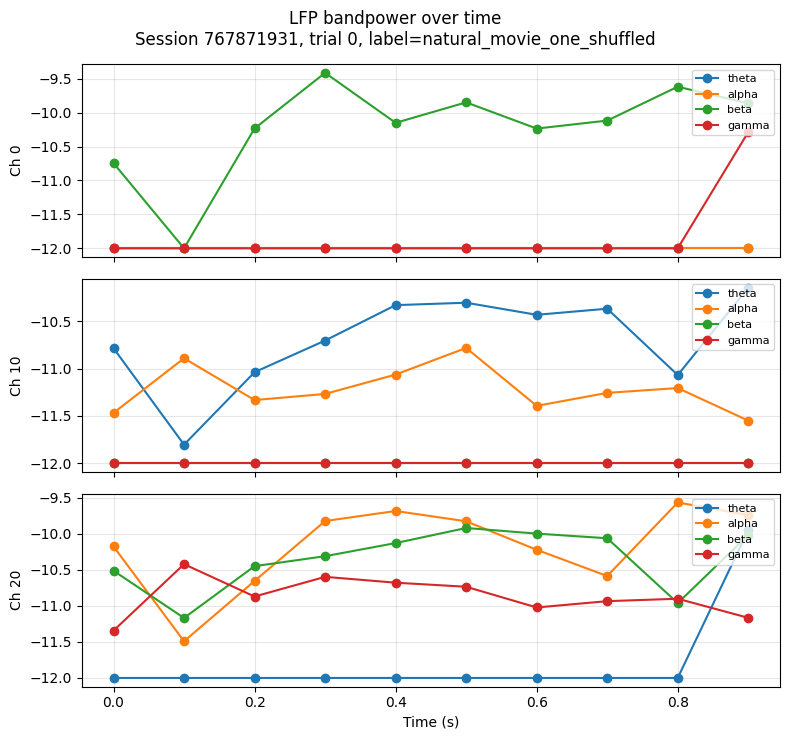

In [3]:
data_dir = "/projectnb/cs523aw/students/pangelos/RetreivedData"
sid      = 767871931
common_D = 532  # from your cropping script

feat_path = os.path.join(data_dir, f"bp_time_features_rich{common_D}_{sid}.npy")
lab_path  = os.path.join(data_dir, f"bp_time_labels_rich{common_D}_{sid}.npy")

X = np.load(feat_path)   # (N, K, D)
y = np.load(lab_path, allow_pickle=True)

N, K, D = X.shape
print("X shape:", X.shape)
print("Example labels:", np.unique(y))
print("D =", D)

# --- infer channels and bands from your feature construction ---
n_bands = 4  # theta, alpha, beta, gamma
assert D % n_bands == 0, "D is not divisible by n_bands; check your feature layout."
n_channels = D // n_bands
print("Inferred n_channels =", n_channels)

band_names = ["theta", "alpha", "beta", "gamma"]

# --- pick a trial to visualize ---
trial_idx = 0
trial = X[trial_idx]   # (K, D)
label = y[trial_idx]
print("Selected label:", label)

# reshape to (K, channels, bands)
trial_reshaped = trial.reshape(K, n_channels, n_bands)  # (K, C, 4)

# --- choose a subset of channels to plot ---
channels_to_plot = [0, min(10, n_channels-1), min(20, n_channels-1)]
time_bins = np.arange(K) * 0.1  # 10 bins over 1 s → 0.1 s per bin

fig, axes = plt.subplots(len(channels_to_plot), 1,
                         figsize=(8, 2.5 * len(channels_to_plot)),
                         sharex=True)

if len(channels_to_plot) == 1:
    axes = [axes]

for ax, ch in zip(axes, channels_to_plot):
    bp = trial_reshaped[:, ch, :]   # (K, n_bands)
    for b in range(n_bands):
        ax.plot(time_bins, bp[:, b], marker="o", label=band_names[b])
    ax.set_ylabel(f"Ch {ch}")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"LFP bandpower over time\nSession {sid}, trial {trial_idx}, label={label}", y=0.98)
plt.tight_layout()
plt.show()


X shape: (13785, 10, 532)


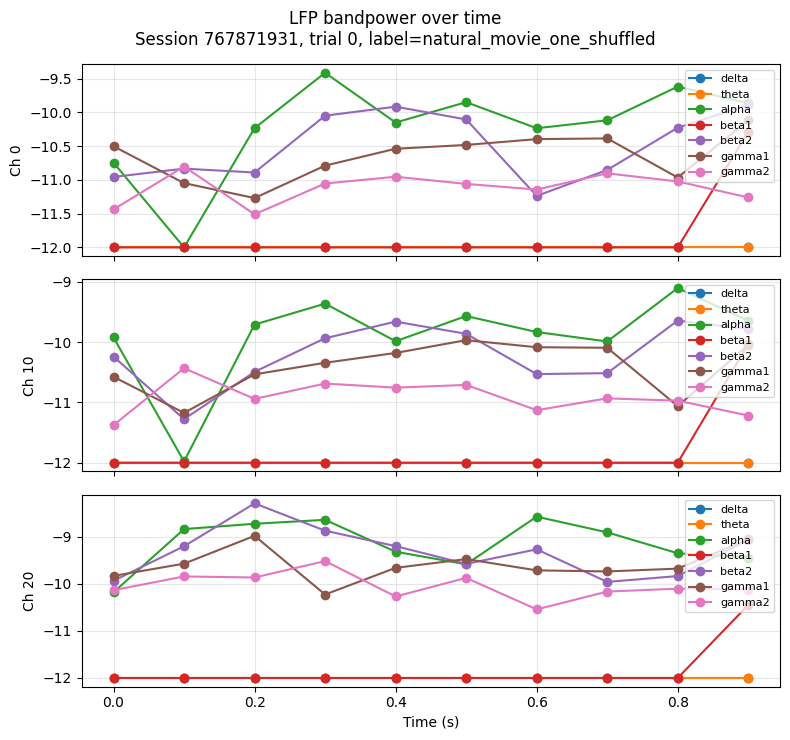

In [10]:
data_dir = "/projectnb/cs523aw/students/pangelos/RetreivedData"
sid      = 767871931          # pick a session you have
common_D = 532                # or whatever you actually saved

feat_path = os.path.join(data_dir, f"bp_time_features_rich{common_D}_{sid}.npy")
lab_path  = os.path.join(data_dir, f"bp_time_labels_rich{common_D}_{sid}.npy")

X = np.load(feat_path)   # (N, K, D)
y = np.load(lab_path, allow_pickle=True)

N, K, D = X.shape
print("X shape:", X.shape)

# Your rich features used 7 bands; infer channels from D
n_bands = 7
assert D % n_bands == 0
n_channels = D // n_bands
band_names = ["delta","theta","alpha","beta1","beta2","gamma1","gamma2"]

trial_idx = 0
trial = X[trial_idx]       # (K, D)
label = y[trial_idx]

# (K, D) -> (K, channels, bands)
trial_reshaped = trial.reshape(K, n_channels, n_bands)

channels_to_plot = [0, 10, 20]
time_bins = np.arange(K) * 0.1   # 10 bins over 1 s

fig, axes = plt.subplots(len(channels_to_plot), 1,
                         figsize=(8, 2.5 * len(channels_to_plot)),
                         sharex=True)

if len(channels_to_plot) == 1:
    axes = [axes]

for ax, ch in zip(axes, channels_to_plot):
    bp = trial_reshaped[:, ch, :]   # (K, n_bands)
    for b in range(n_bands):
        ax.plot(time_bins, bp[:, b], marker="o", label=band_names[b])
    ax.set_ylabel(f"Ch {ch}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"LFP bandpower over time\nSession {sid}, trial {trial_idx}, label={label}", y=0.98)
plt.tight_layout()
plt.show()


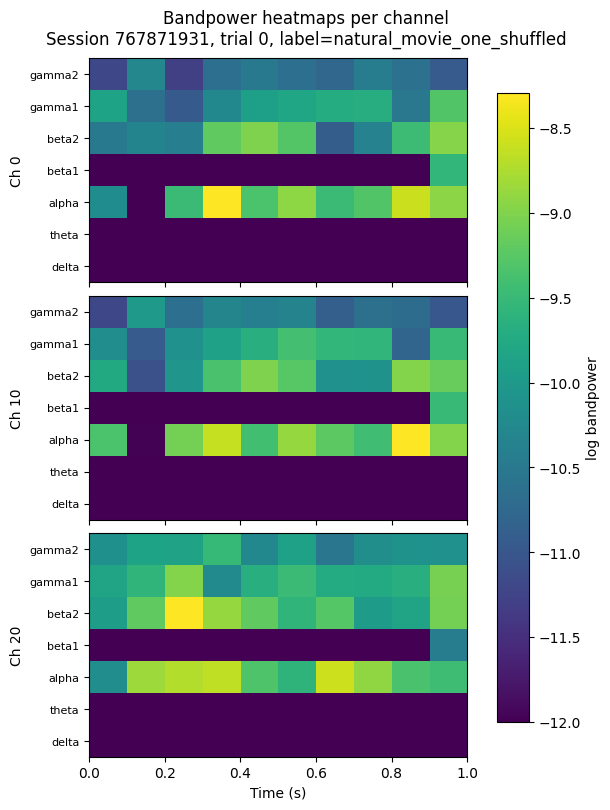

In [15]:
channels_to_plot = [0, 10, 20]
n_bands = trial_reshaped.shape[2]
time_bins = np.linspace(0, 1.0, K+1)

fig, axes = plt.subplots(
    len(channels_to_plot), 1,
    figsize=(6, 2.5 * len(channels_to_plot)),
    sharex=True, sharey=True,
    constrained_layout=True
)

if len(channels_to_plot) == 1:
    axes = [axes]

for ax, ch in zip(axes, channels_to_plot):
    bp = trial_reshaped[:, ch, :].T   # (bands, K)
    im = ax.imshow(
        bp,
        aspect="auto",
        origin="lower",
        extent=[0, 1.0, 0, n_bands]
    )
    ax.set_yticks(np.arange(n_bands) + 0.5)
    ax.set_yticklabels(band_names, fontsize=8)
    ax.set_ylabel(f"Ch {ch}")

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Bandpower heatmaps per channel\nSession {sid}, trial {trial_idx}, label={label}",
    y=1.06
)

# Single colorbar for the whole figure, placed to the right
cbar = fig.colorbar(im, ax=axes, shrink=0.9, label="log bandpower", location="right")
plt.show()
